Number of observations:  2001
vx max:  0.78009385
vy max:  0.68557113
vtheta max:  1.0058111
eevx max:  0.88008904
eevy max:  0.7654628
eevz max:  0.72715676
eervx max:  0.885375
eervy max:  0.99999315
eervz max:  0.9467251


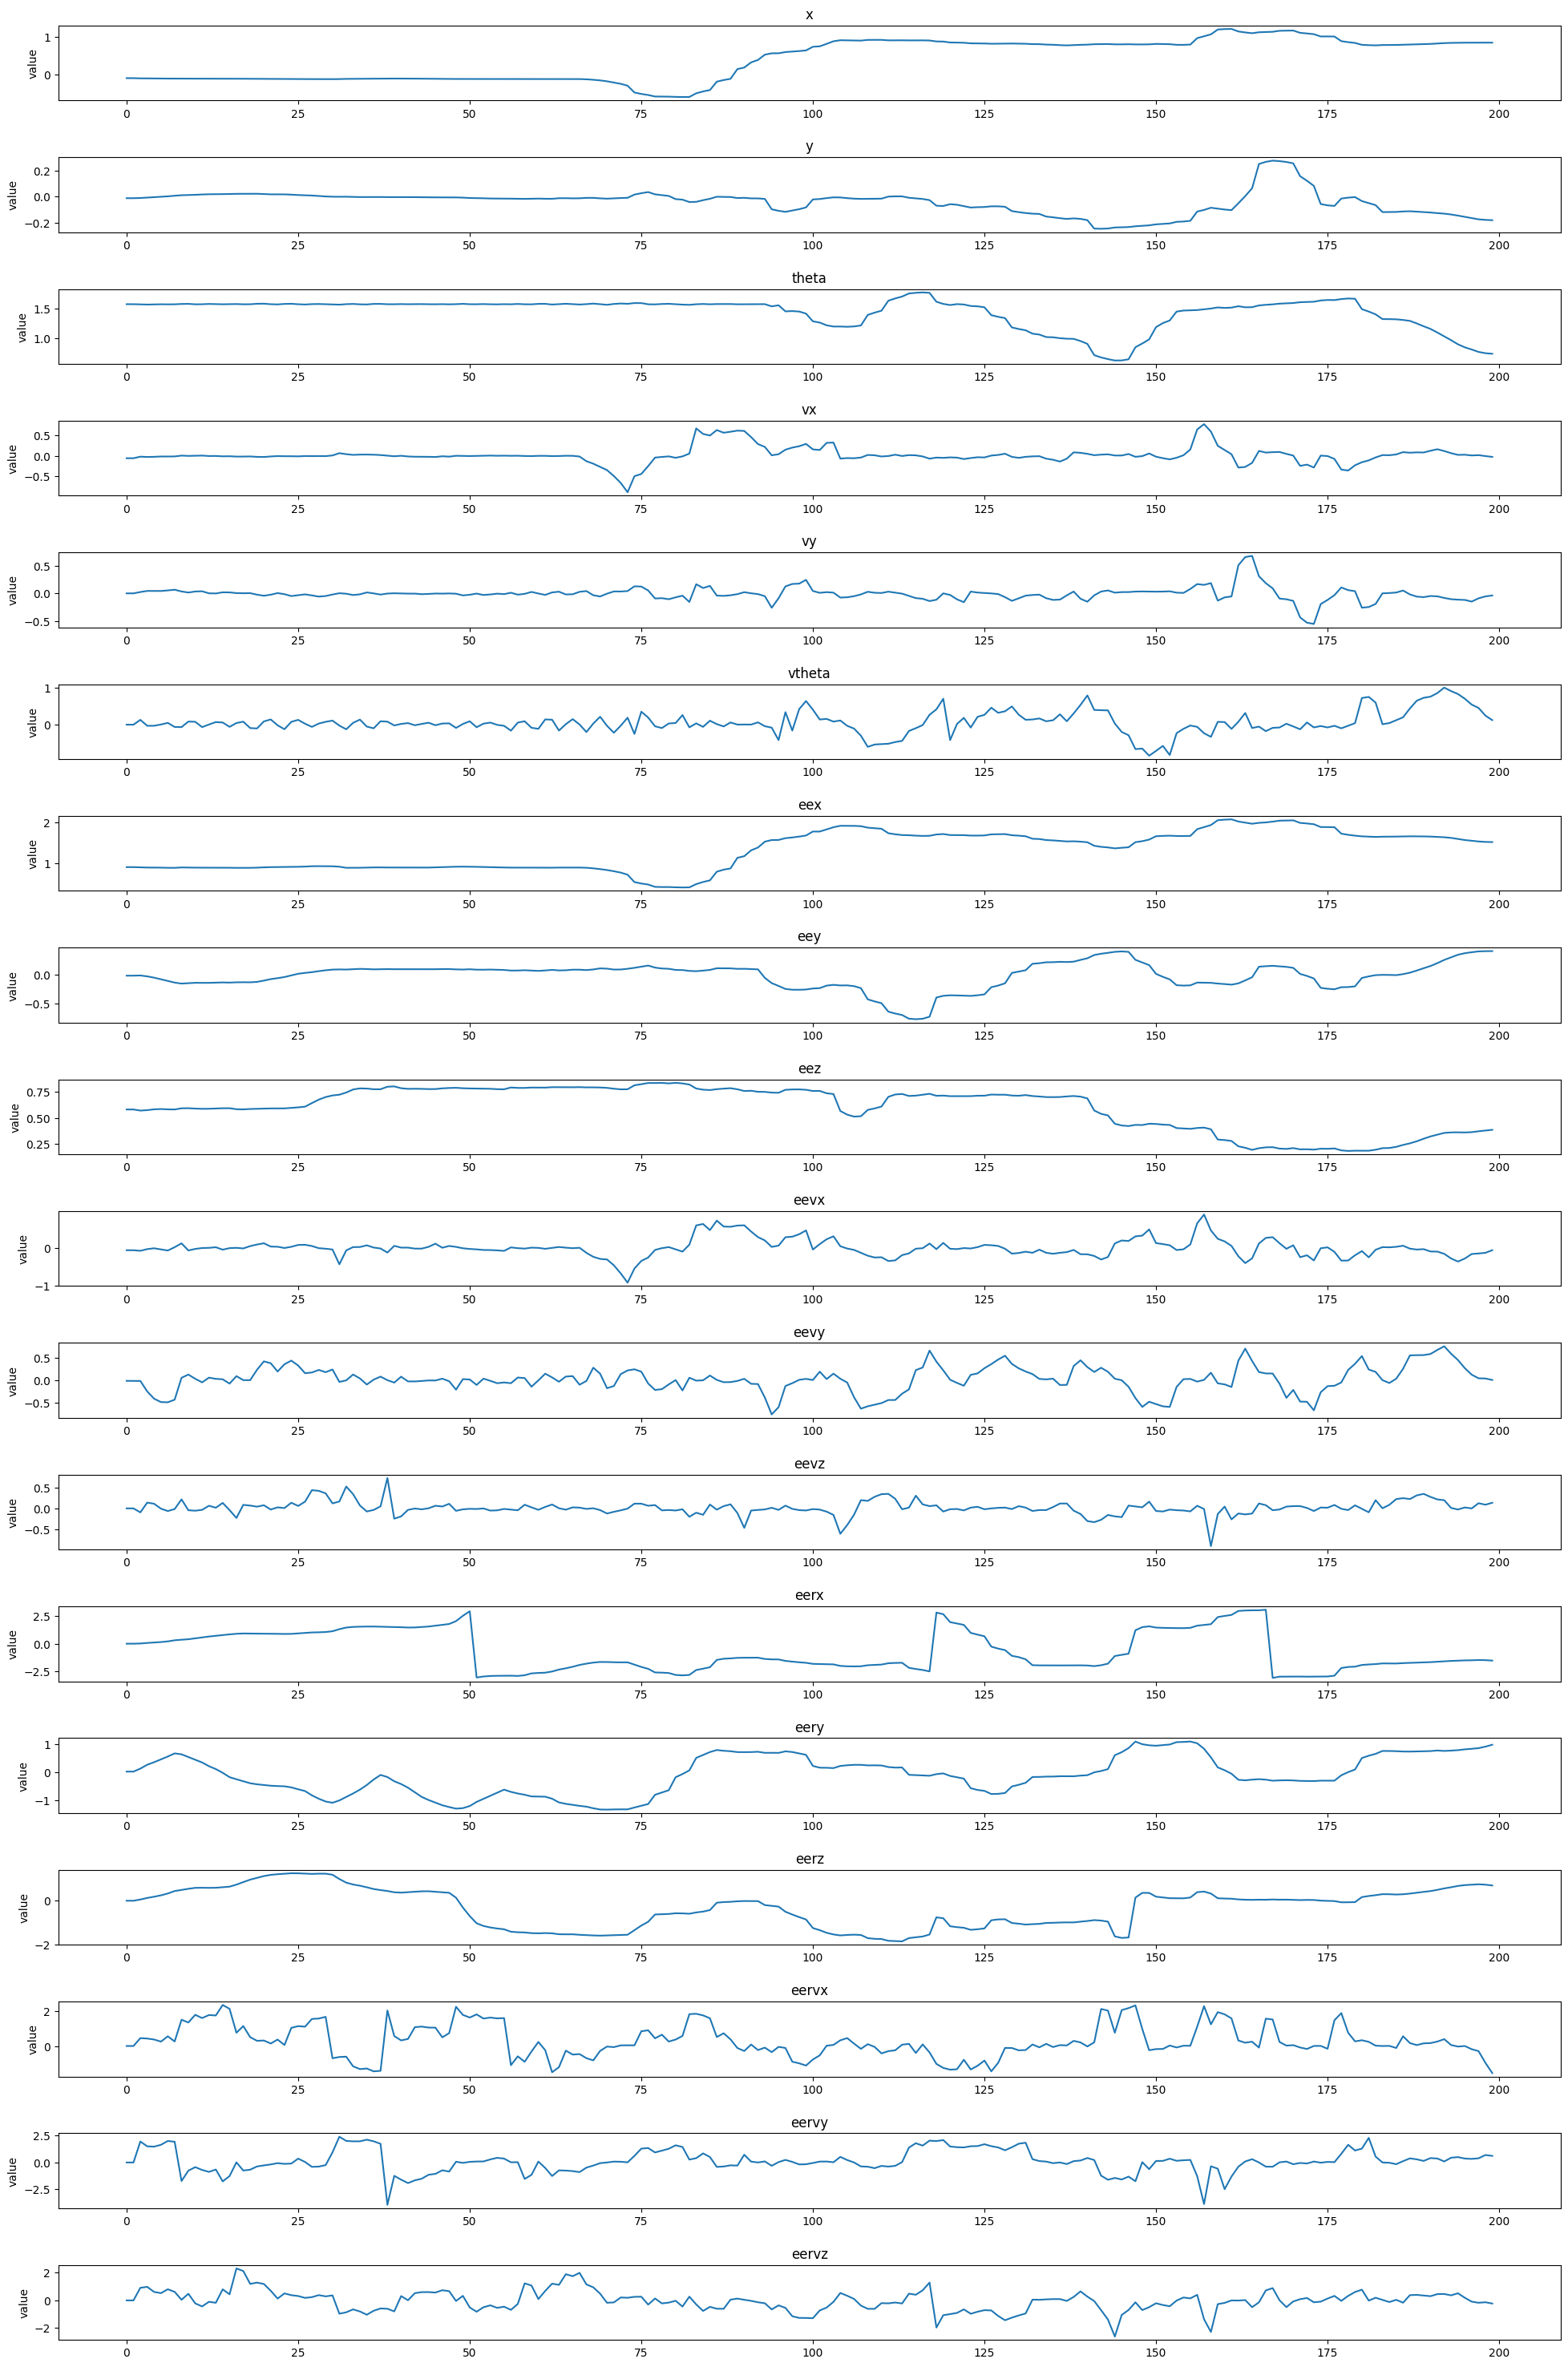

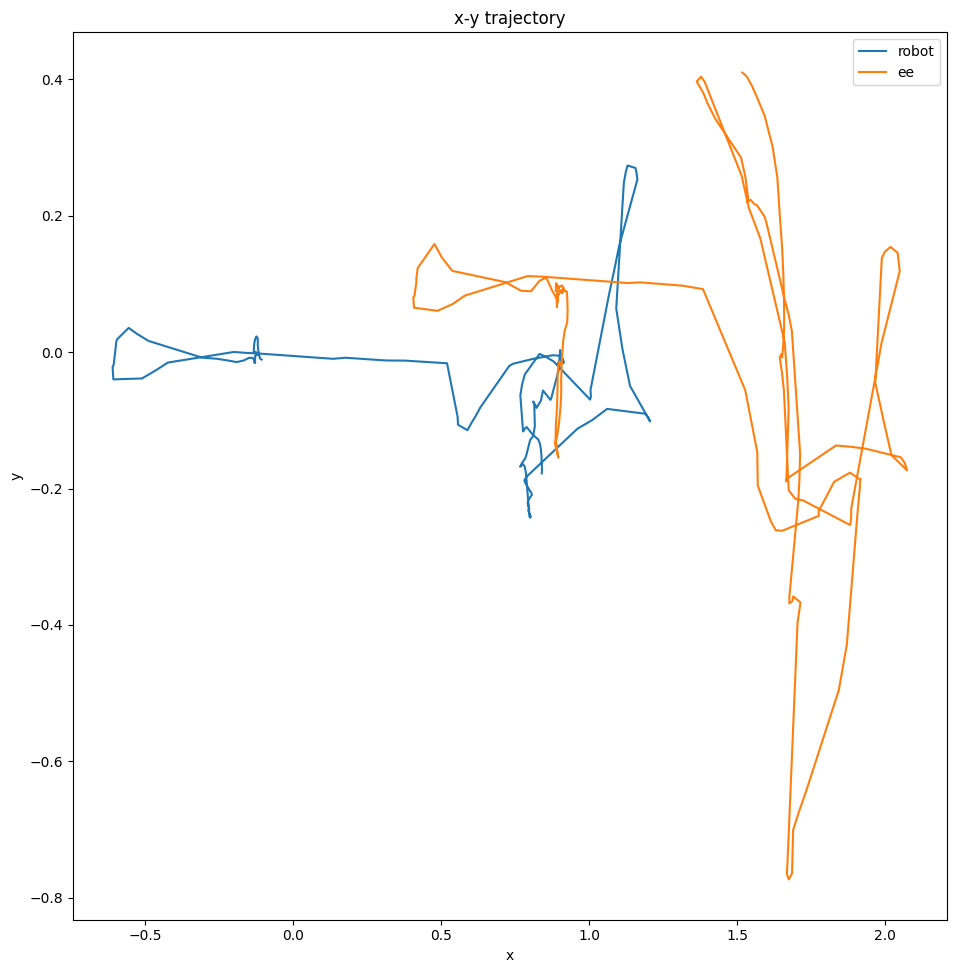

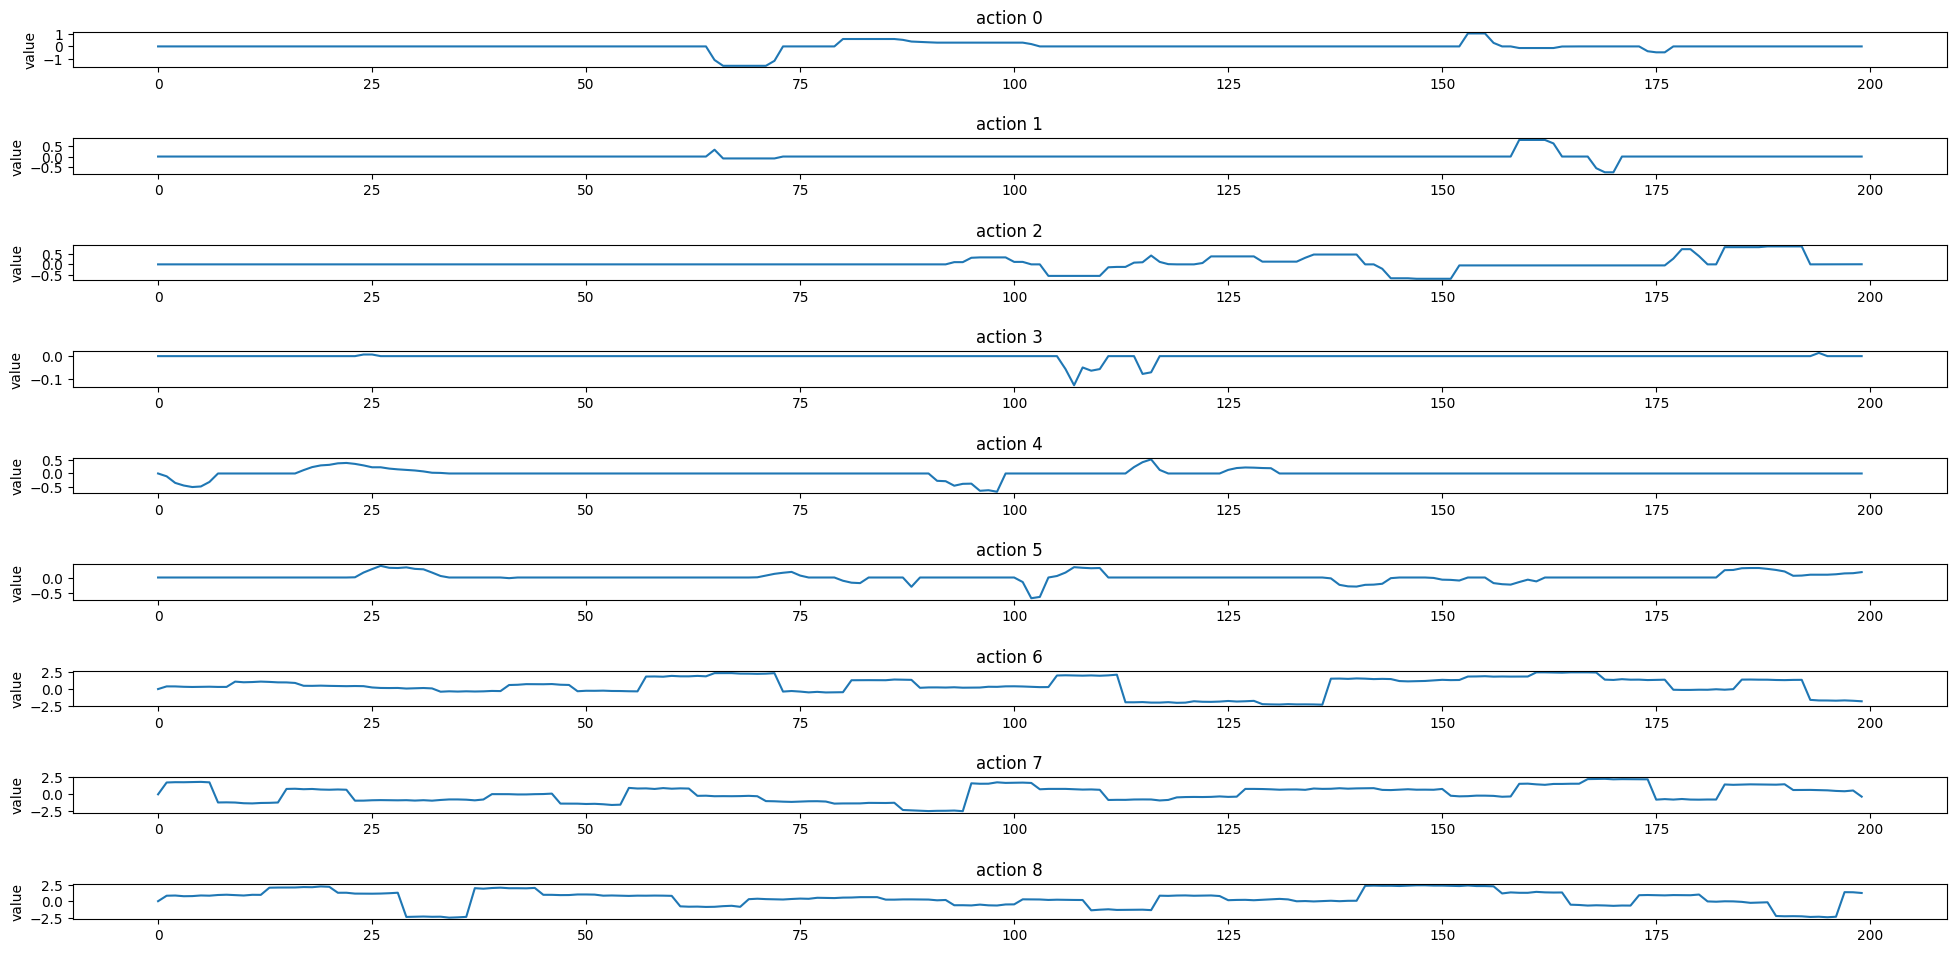

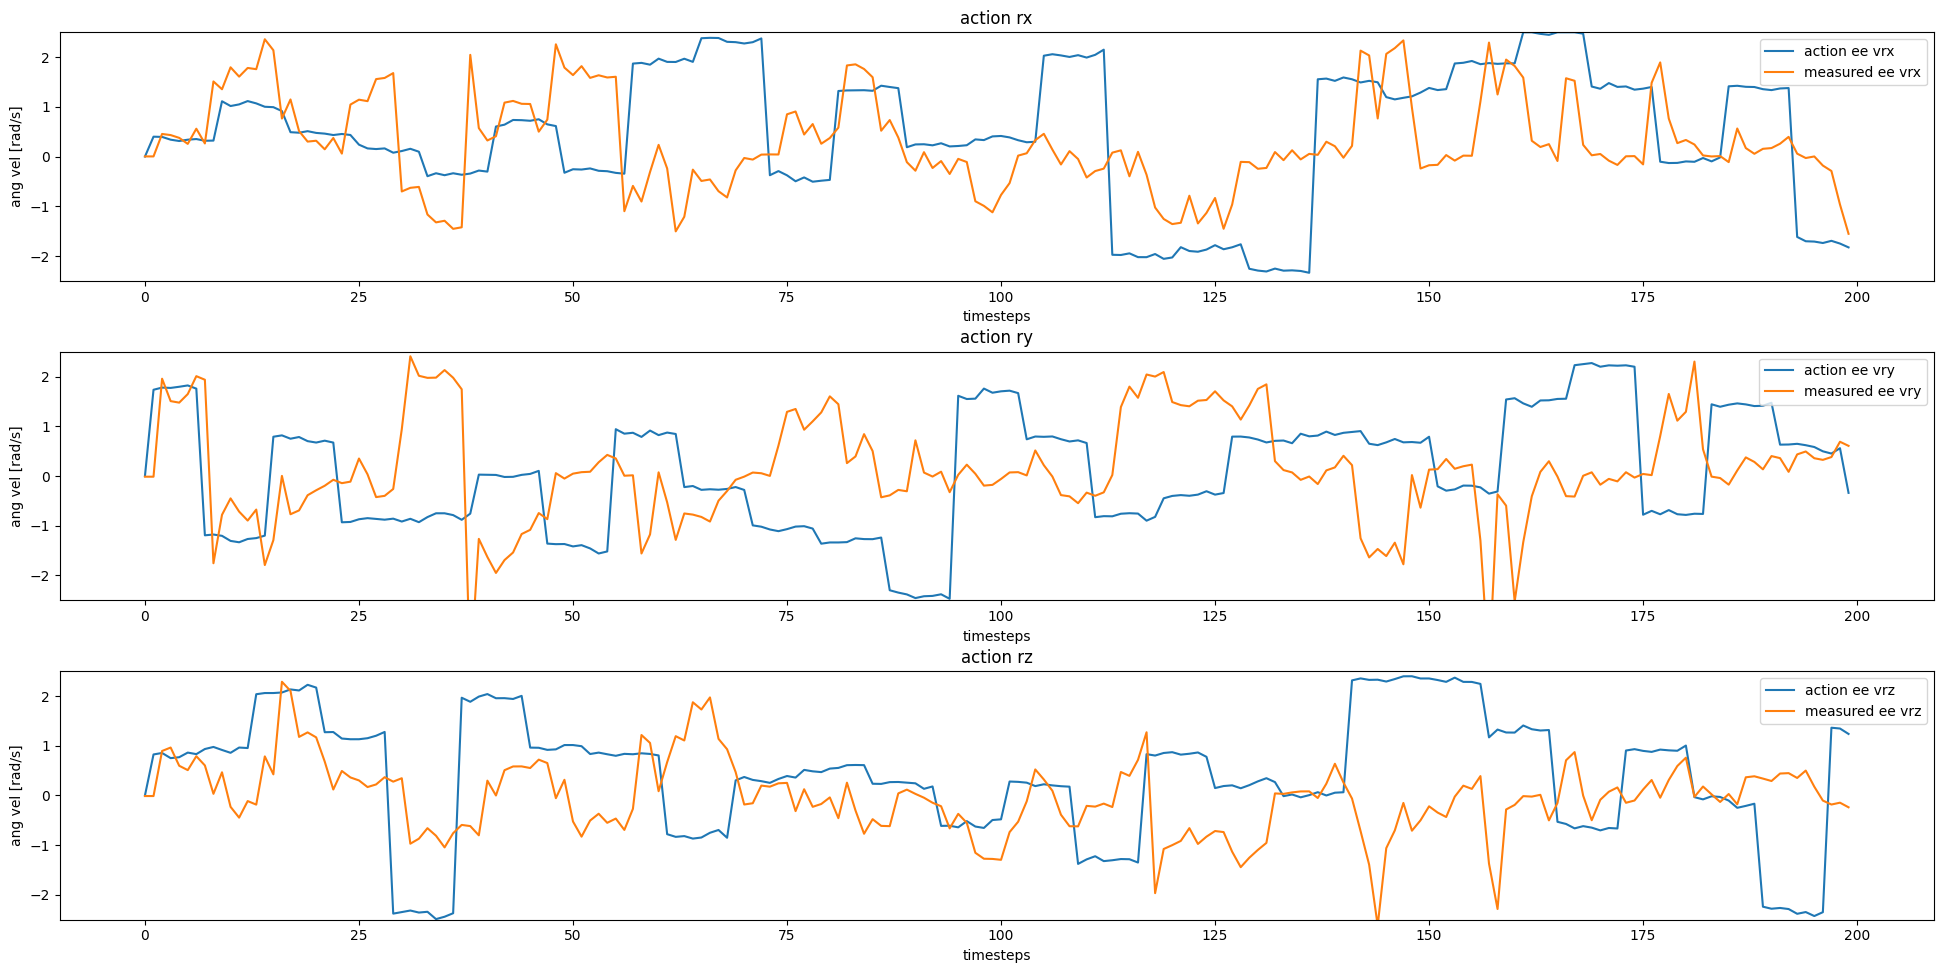

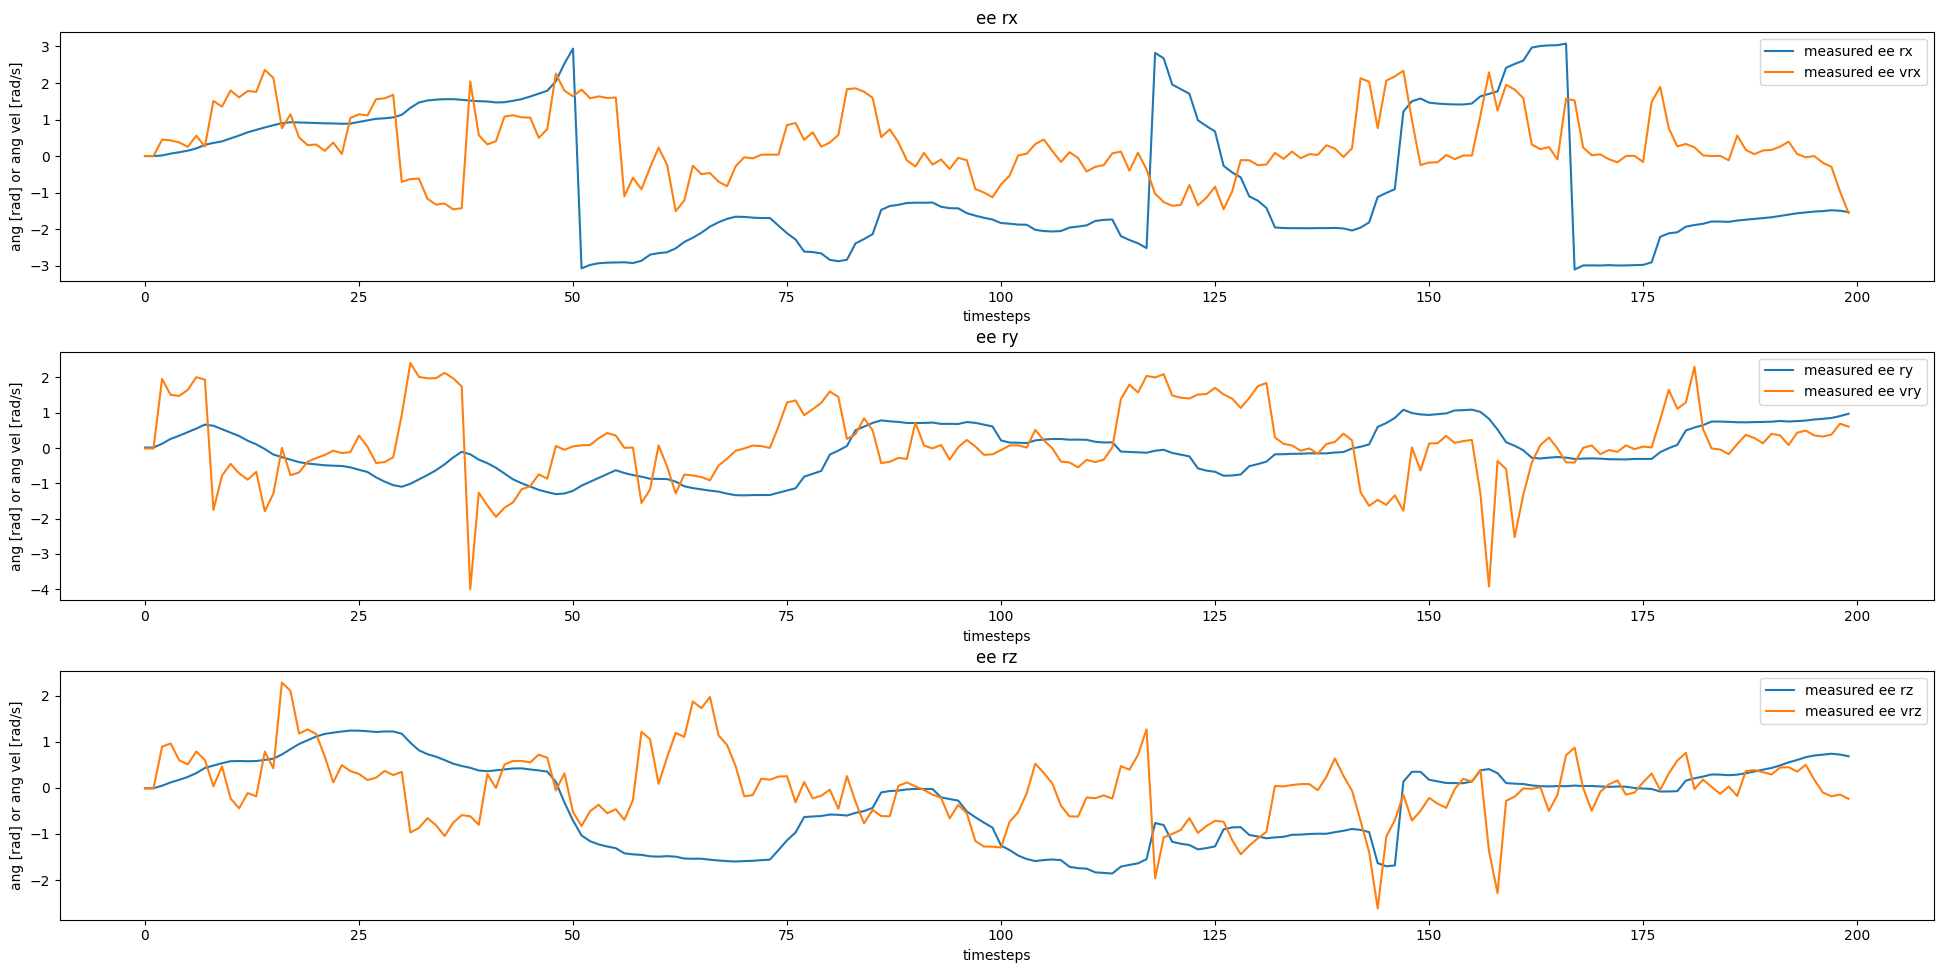

In [2]:
"""Analyse data collected on real robot"""

import os
import pickle
import numpy as np
import jax.numpy as jnp

v0 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v0/brax_transitions_v0.pickle"
v1 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v0/brax_transitions_v1.pickle"
v2 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v0/brax_transitions_v2.pickle"
v3 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v0/brax_transitions_v3.pickle"
v4 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v0/brax_transitions_v4.pickle"

v5 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v1/brax_transitions_v0.pickle"
v6 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v1/brax_transitions_v1.pickle"
v7 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v1/brax_transitions_v2.pickle"
v8 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v1/brax_transitions_v3.pickle"
v9 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v1/brax_transitions_v4.pickle"
v10 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v1/brax_transitions_v5.pickle"

v11 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v2/brax_transitions_v0.pickle"
v12 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v2/brax_transitions_v1.pickle"
v13 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v2/brax_transitions_v2.pickle"
v14 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v2/brax_transitions_v3.pickle"
v15 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v2/brax_transitions_v4.pickle"
v16 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v2/brax_transitions_v5.pickle"
v17 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v2/brax_transitions_v6.pickle"
v18 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v2/brax_transitions_v7.pickle"
v19 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v2/brax_transitions_v8.pickle"

vrx_00 = "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/collected_data/test20241105-165528_vrx_testing/brax_transitions.pickle"
vrx_01 = "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/collected_data/test20241105-165656_vrx_testing_01/brax_transitions.pickle"
vrx_02 = "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/collected_data/test20241105-170634_vrx_testing_02/brax_transitions.pickle"
vrx_03 = "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/collected_data/test20241105-171728_vrx_testing_03/brax_transitions.pickle"

file_names = [v0, v1, v2, v3, v4, v5, v6, v7, v8, v9, v10, v11,
              v12, v13, v14, v15, v16, v17, v18, v19,]


state_label_dict = {
    0: "x",
    1: "y",
    2: "sin_theta",
    3: "cos_theta",
    4: "vx",
    5: "vy",
    6: "vtheta",
    7: "eex",
    8: "eey",
    9: "eez",
    10: "eevx",
    11: "eevy",
    12: "eevz",
    13: "sin_eerx",
    14: "cos_eerx",
    15: "sin_eery",
    16: "cos_eery",
    17: "sin_eerz",
    18: "cos_eerz",
    19: "eervx",
    20: "eervy",
    21: "eervz"
}

state_label_dict_cleaned = {
    0: "x",
    1: "y",
    2: "theta",
    3: "vx",
    4: "vy",
    5: "vtheta",
    6: "eex",
    7: "eey",
    8: "eez",
    9: "eevx",
    10: "eevy",
    11: "eevz",
    12: "eerx",
    13: "eery",
    14: "eerz",
    15: "eervx",
    16: "eervy",
    17: "eervz"
}


def load_data(file_names):

    data = []
    for file_name in file_names:
        with open(file_name, "rb") as f:
            data += pickle.load(f)
    return data

data = load_data(file_names)

observations = [x.observation for x in data]
actions = [x.action for x in data]

print("Number of observations: ", len(observations))
import matplotlib.pyplot as plt
import seaborn as sns

observations = np.array(observations)

# cut at 200
observations = observations[:200]
actions = actions[:200]

print("vx max: ", np.max(observations[:, 4]))
print("vy max: ", np.max(observations[:, 5]))
print("vtheta max: ", np.max(observations[:, 6]))
print("eevx max: ", np.max(observations[:, 10]))
print("eevy max: ", np.max(observations[:, 11]))
print("eevz max: ", np.max(observations[:, 12]))
print("eervx max: ", np.max(observations[:, 15]))
print("eervy max: ", np.max(observations[:, 16]))
print("eervz max: ", np.max(observations[:, 17]))

theta = np.arctan2(observations[:, 3], observations[:, 2])
ee_rx = np.arctan2(observations[:, 13], observations[:, 14])
ee_ry = np.arctan2(observations[:, 15], observations[:, 16])
ee_rz = np.arctan2(observations[:, 17], observations[:, 18])

# cast between -pi and pi
theta = np.array([jnp.arctan2(jnp.sin(x), jnp.cos(x)) for x in theta])
ee_rx = np.array([jnp.arctan2(jnp.sin(x), jnp.cos(x)) for x in ee_rx])
ee_ry = np.array([jnp.arctan2(jnp.sin(x), jnp.cos(x)) for x in ee_ry])
ee_rz = np.array([jnp.arctan2(jnp.sin(x), jnp.cos(x)) for x in ee_rz])


# plot everything
n_plots = len(state_label_dict_cleaned)

obsertvations_cleaned = np.zeros((observations.shape[0], n_plots))
obsertvations_cleaned[:, 0] = observations[:, 0]
obsertvations_cleaned[:, 1] = observations[:, 1]
obsertvations_cleaned[:, 2] = theta
obsertvations_cleaned[:, 3] = observations[:, 4]
obsertvations_cleaned[:, 4] = observations[:, 5]
obsertvations_cleaned[:, 5] = observations[:, 6]
obsertvations_cleaned[:, 6] = observations[:, 7]
obsertvations_cleaned[:, 7] = observations[:, 8]
obsertvations_cleaned[:, 8] = observations[:, 9]
obsertvations_cleaned[:, 9] = observations[:, 10]
obsertvations_cleaned[:, 10] = observations[:, 11]
obsertvations_cleaned[:, 11] = observations[:, 12]
obsertvations_cleaned[:, 12] = ee_rx
obsertvations_cleaned[:, 13] = ee_ry
obsertvations_cleaned[:, 14] = ee_rz
obsertvations_cleaned[:, 15] = observations[:, 19]
obsertvations_cleaned[:, 16] = observations[:, 20]
obsertvations_cleaned[:, 17] = observations[:, 21]


fig, axs = plt.subplots(n_plots, 1, figsize=(20, 30))
# add some space between subplots
fig.tight_layout(pad=3.0)

for i in range(n_plots):
    axs[i].plot(obsertvations_cleaned[:, i])
    axs[i].set_title(state_label_dict_cleaned[i])
    axs[i].set_ylabel("value")

plt.show()

# plot x,y ee_x, ee_y 2d trajectory
fig, axs = plt.subplots(1, 1, figsize=(10, 10))
# add some space between subplots
fig.tight_layout(pad=3.0)

axs.plot(obsertvations_cleaned[:, 0], obsertvations_cleaned[:, 1], label="robot")
axs.plot(obsertvations_cleaned[:, 6], obsertvations_cleaned[:, 7], label="ee")
axs.set_title("x-y trajectory")
axs.set_xlabel("x")
axs.set_ylabel("y")
axs.legend()
plt.show()


# plot actions
actions = np.array(actions)
fig, axs = plt.subplots(9, 1, figsize=(20, 10))
# add some space between subplots
fig.tight_layout(pad=3.0)

for i in range(9):
    axs[i].plot(actions[:, i])
    axs[i].set_title("action " + str(i))
    axs[i].set_ylabel("value")


# plot ee vrx, ee vry, ee vrz on top of actions
fig, axs = plt.subplots(3, 1, figsize=(20, 10))
# add some space between subplots
fig.tight_layout(pad=3.0)
labels = ["rx", "ry", "rz"]
for i in range(3):
    axs[i].plot(actions[:, i+6], label=f"action ee v{labels[i]}")
    axs[i].plot(obsertvations_cleaned[:, 15+i], label=f"measured ee v{labels[i]}")
    axs[i].set_title("action " + labels[i])
    axs[i].set_ylabel("ang vel [rad/s]")
    axs[i].set_xlabel("timesteps")
    # make legend always in top right
    axs[i].legend(loc='upper right')    
    # scale y from 0 to 1
    axs[i].set_ylim(-2.5, 2.5)
plt.show()

# plot ee rx, ee ry, ee rz on top of ee vrx, ee vry, ee vrz
fig, axs = plt.subplots(3, 1, figsize=(20, 10))
# add some space between subplots
fig.tight_layout(pad=3.0)
labels = ["rx", "ry", "rz"]
for i in range(3):
    axs[i].plot(obsertvations_cleaned[:, 12+i], label=f"measured ee {labels[i]}")
    axs[i].plot(obsertvations_cleaned[:, 15+i], label=f"measured ee v{labels[i]}")
    axs[i].set_title("ee " + labels[i])
    axs[i].set_ylabel("ang [rad] or ang vel [rad/s]")
    axs[i].set_xlabel("timesteps")
    # make legend always in top right
    axs[i].legend(loc='upper right')
plt.show()